### Проверка GPU и CUDA

In [1]:
!nvidia-smi
!nvcc --version

Tue Mar 31 15:56:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Создание файла matrix_mul.cu

In [2]:
%%writefile matrix_mul.cu
#include <cuda_runtime.h>

#include <iostream>
#include <vector>
#include <random>
#include <chrono>
#include <iomanip>
#include <cmath>
#include <fstream>
#include <algorithm>
#include <numeric>
#include <cstdlib>

// Макрос для проверки CUDA-вызовов
#define CUDA_CHECK(call)                                                     \
do {                                                                         \
    cudaError_t err = (call);                                                \
    if (err != cudaSuccess) {                                                \
        std::cerr << "CUDA error: " << cudaGetErrorString(err)               \
                  << " | line: " << __LINE__ << std::endl;                   \
        std::exit(EXIT_FAILURE);                                             \
    }                                                                        \
} while (0)

// Размер тайла для shared memory
constexpr int TILE = 16;

// Количество повторов для каждого размера матрицы
constexpr int REPEATS = 3;

struct Result {
    int size;
    double cpu_ms;
    float gpu_kernel_ms;
    double gpu_total_ms;
    double speedup_total;
    bool correct;
    float max_error;
};

// Заполнение матрицы случайными числами
void fillRandom(std::vector<float>& mat) {
    static std::mt19937 gen(42);
    static std::uniform_real_distribution<float> dist(-1.0f, 1.0f);

    for (auto& x : mat) {
        x = dist(gen);
    }
}

// CPU-умножение матриц
// Используется порядок циклов i-k-j, который обычно работает быстрее,
// чем классический i-j-k, из-за более удобного доступа к памяти
void multiplyCPU(const std::vector<float>& A,
                 const std::vector<float>& B,
                 std::vector<float>& C,
                 int N) {
    std::fill(C.begin(), C.end(), 0.0f);

    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < N; ++k) {
            float a = A[i * N + k];
            const float* bRow = &B[k * N];
            float* cRow = &C[i * N];

            for (int j = 0; j < N; ++j) {
                cRow[j] += a * bRow[j];
            }
        }
    }
}

// Пустое ядро для прогрева CUDA-контекста
__global__ void warmupKernel() {}

// GPU-ядро умножения матриц
// Каждый поток вычисляет один элемент результирующей матрицы C[row][col]
// Используется tiled-подход: данные по частям загружаются в shared memory
__global__ void multiplyGPUKernel(const float* A,
                                  const float* B,
                                  float* C,
                                  int N) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;

    float sum = 0.0f;
    int numTiles = (N + TILE - 1) / TILE;

    for (int t = 0; t < numTiles; ++t) {
        int aCol = t * TILE + threadIdx.x;
        int bRow = t * TILE + threadIdx.y;

        if (row < N && aCol < N)
            As[threadIdx.y][threadIdx.x] = A[row * N + aCol];
        else
            As[threadIdx.y][threadIdx.x] = 0.0f;

        if (bRow < N && col < N)
            Bs[threadIdx.y][threadIdx.x] = B[bRow * N + col];
        else
            Bs[threadIdx.y][threadIdx.x] = 0.0f;

        __syncthreads();

        for (int e = 0; e < TILE; ++e) {
            sum += As[threadIdx.y][e] * Bs[e][threadIdx.x];
        }

        __syncthreads();
    }

    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

// Полный запуск GPU-версии:
// 1) выделение памяти на GPU
// 2) копирование A и B на устройство
// 3) запуск CUDA-ядра
// 4) копирование результата обратно
void multiplyGPU(const std::vector<float>& A,
                 const std::vector<float>& B,
                 std::vector<float>& C,
                 int N,
                 float& kernel_ms,
                 double& total_ms) {
    float* dA = nullptr;
    float* dB = nullptr;
    float* dC = nullptr;

    size_t bytes = static_cast<size_t>(N) * N * sizeof(float);

    CUDA_CHECK(cudaMalloc(&dA, bytes));
    CUDA_CHECK(cudaMalloc(&dB, bytes));
    CUDA_CHECK(cudaMalloc(&dC, bytes));

    cudaEvent_t startKernel, stopKernel;
    CUDA_CHECK(cudaEventCreate(&startKernel));
    CUDA_CHECK(cudaEventCreate(&stopKernel));

    auto totalStart = std::chrono::high_resolution_clock::now();

    CUDA_CHECK(cudaMemcpy(dA, A.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(dB, B.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    CUDA_CHECK(cudaEventRecord(startKernel));
    multiplyGPUKernel<<<grid, block>>>(dA, dB, dC, N);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaEventRecord(stopKernel));
    CUDA_CHECK(cudaEventSynchronize(stopKernel));

    CUDA_CHECK(cudaEventElapsedTime(&kernel_ms, startKernel, stopKernel));

    CUDA_CHECK(cudaMemcpy(C.data(), dC, bytes, cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaDeviceSynchronize());

    auto totalEnd = std::chrono::high_resolution_clock::now();
    total_ms = std::chrono::duration<double, std::milli>(totalEnd - totalStart).count();

    CUDA_CHECK(cudaEventDestroy(startKernel));
    CUDA_CHECK(cudaEventDestroy(stopKernel));

    CUDA_CHECK(cudaFree(dA));
    CUDA_CHECK(cudaFree(dB));
    CUDA_CHECK(cudaFree(dC));
}

// Проверка совпадения результатов CPU и GPU
bool verifyResults(const std::vector<float>& cpu,
                   const std::vector<float>& gpu,
                   float& max_error,
                   float eps = 1e-3f) {
    max_error = 0.0f;

    for (size_t i = 0; i < cpu.size(); ++i) {
        float diff = std::fabs(cpu[i] - gpu[i]);
        max_error = std::max(max_error, diff);

        float tol = eps * (1.0f + std::fabs(cpu[i]));
        if (diff > tol) {
            return false;
        }
    }
    return true;
}

// Среднее значение вектора чисел
template <typename T>
double average(const std::vector<T>& values) {
    double sum = 0.0;
    for (const auto& v : values) {
        sum += static_cast<double>(v);
    }
    return sum / values.size();
}

// Эксперимент для одного размера матрицы
// Каждый тест повторяется REPEATS раз, затем берётся среднее время
Result runExperiment(int N) {
    std::vector<float> A(static_cast<size_t>(N) * N);
    std::vector<float> B(static_cast<size_t>(N) * N);
    std::vector<float> Ccpu(static_cast<size_t>(N) * N);
    std::vector<float> Cgpu(static_cast<size_t>(N) * N);

    fillRandom(A);
    fillRandom(B);

    std::vector<double> cpuTimes;
    std::vector<float> gpuKernelTimes;
    std::vector<double> gpuTotalTimes;

    cpuTimes.reserve(REPEATS);
    gpuKernelTimes.reserve(REPEATS);
    gpuTotalTimes.reserve(REPEATS);

    // Повторы CPU-версии
    for (int r = 0; r < REPEATS; ++r) {
        auto cpuStart = std::chrono::high_resolution_clock::now();
        multiplyCPU(A, B, Ccpu, N);
        auto cpuEnd = std::chrono::high_resolution_clock::now();

        double cpu_ms = std::chrono::duration<double, std::milli>(cpuEnd - cpuStart).count();
        cpuTimes.push_back(cpu_ms);
    }

    // Повторы GPU-версии
    for (int r = 0; r < REPEATS; ++r) {
        float gpu_kernel_ms = 0.0f;
        double gpu_total_ms = 0.0;

        multiplyGPU(A, B, Cgpu, N, gpu_kernel_ms, gpu_total_ms);

        gpuKernelTimes.push_back(gpu_kernel_ms);
        gpuTotalTimes.push_back(gpu_total_ms);
    }

    float max_error = 0.0f;
    bool correct = verifyResults(Ccpu, Cgpu, max_error);

    Result result;
    result.size = N;
    result.cpu_ms = average(cpuTimes);
    result.gpu_kernel_ms = static_cast<float>(average(gpuKernelTimes));
    result.gpu_total_ms = average(gpuTotalTimes);
    result.speedup_total = result.cpu_ms / result.gpu_total_ms;
    result.correct = correct;
    result.max_error = max_error;

    return result;
}

// Сохранение результатов в CSV
void saveCSV(const std::vector<Result>& results, const std::string& filename) {
    std::ofstream file(filename);
    file << "size,cpu_ms,gpu_kernel_ms,gpu_total_ms,speedup_total,correct,max_error\n";

    for (const auto& r : results) {
        file << r.size << ","
             << r.cpu_ms << ","
             << r.gpu_kernel_ms << ","
             << r.gpu_total_ms << ","
             << r.speedup_total << ","
             << (r.correct ? 1 : 0) << ","
             << r.max_error << "\n";
    }
}

int main() {
    int deviceCount = 0;
    cudaError_t err = cudaGetDeviceCount(&deviceCount);

    if (err != cudaSuccess || deviceCount == 0) {
        std::cout << "CUDA device not found.\n";
        return 1;
    }

    CUDA_CHECK(cudaSetDevice(0));

    cudaDeviceProp prop{};
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));

    std::cout << "GPU: " << prop.name << "\n";
    std::cout << "Compute capability: " << prop.major << "." << prop.minor << "\n";
    std::cout << "Repeats for each size: " << REPEATS << "\n\n";

    // Прогрев CUDA перед серией измерений
    CUDA_CHECK(cudaFree(0));
    warmupKernel<<<1, 1>>>();
    CUDA_CHECK(cudaDeviceSynchronize());

    std::vector<int> sizes = {100, 250, 500, 1000, 1500, 2000};
    std::vector<Result> results;

    std::cout << std::left
              << std::setw(8)  << "Size"
              << std::setw(15) << "CPU avg ms"
              << std::setw(15) << "GPU kernel"
              << std::setw(15) << "GPU total"
              << std::setw(15) << "Speedup"
              << std::setw(10) << "Correct"
              << std::setw(12) << "Max error"
              << "\n";

    std::cout << std::string(90, '-') << "\n";

    for (int n : sizes) {
        std::cout << "Running " << n << "x" << n << " (" << REPEATS << " repeats)...\n";

        Result r = runExperiment(n);
        results.push_back(r);

        std::cout << std::left
                  << std::setw(8)  << r.size
                  << std::setw(15) << std::fixed << std::setprecision(3) << r.cpu_ms
                  << std::setw(15) << std::fixed << std::setprecision(3) << r.gpu_kernel_ms
                  << std::setw(15) << std::fixed << std::setprecision(3) << r.gpu_total_ms
                  << std::setw(15) << std::fixed << std::setprecision(3) << r.speedup_total
                  << std::setw(10) << (r.correct ? "YES" : "NO")
                  << std::setw(12) << std::fixed << std::setprecision(6) << r.max_error
                  << "\n\n";
    }

    saveCSV(results, "results.csv");

    std::cout << "Saved results to results.csv\n";
    return 0;
}

Writing matrix_mul.cu


### Компиляция программы

In [3]:
!nvcc -O2 -std=c++17 matrix_mul.cu -o matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


### Запуск экспериментов

In [4]:
!./matrix_mul

GPU: Tesla T4
Compute capability: 7.5
Repeats for each size: 3

Size    CPU avg ms     GPU kernel     GPU total      Speedup        Correct   Max error   
------------------------------------------------------------------------------------------
Running 100x100 (3 repeats)...
100     0.745          0.022          0.333          2.235          YES       0.000003    

Running 250x250 (3 repeats)...
250     10.390         0.073          0.327          31.818         YES       0.000007    

Running 500x500 (3 repeats)...
500     87.259         0.447          1.365          63.911         YES       0.000010    

Running 1000x1000 (3 repeats)...
1000    672.091        5.560          8.312          80.856         YES       0.000017    

Running 1500x1500 (3 repeats)...
1500    2661.124       18.655         24.453         108.825        YES       0.000027    

Running 2000x2000 (3 repeats)...
2000    6096.910       41.201         51.258         118.946        YES       0.000034    

Saved resu

### Загрузка и просмотр результатов

In [5]:
import pandas as pd

df = pd.read_csv("results.csv")
df_rounded = df.round({
    "cpu_ms": 3,
    "gpu_kernel_ms": 3,
    "gpu_total_ms": 3,
    "speedup_total": 3,
    "max_error": 6
})
df_rounded

,size,cpu_ms,gpu_kernel_ms,gpu_total_ms,speedup_total,correct,max_error
0,100,0.745,0.022,0.333,2.235,1,0.000003
1,250,10.390,0.073,0.327,31.818,1,0.000007
2,500,87.260,0.447,1.365,63.911,1,0.000010
3,1000,672.091,5.560,8.312,80.856,1,0.000017
4,1500,2661.120,18.655,24.453,108.825,1,0.000027
5,2000,6096.910,41.201,51.258,118.946,1,0.000034


### Построение графиков

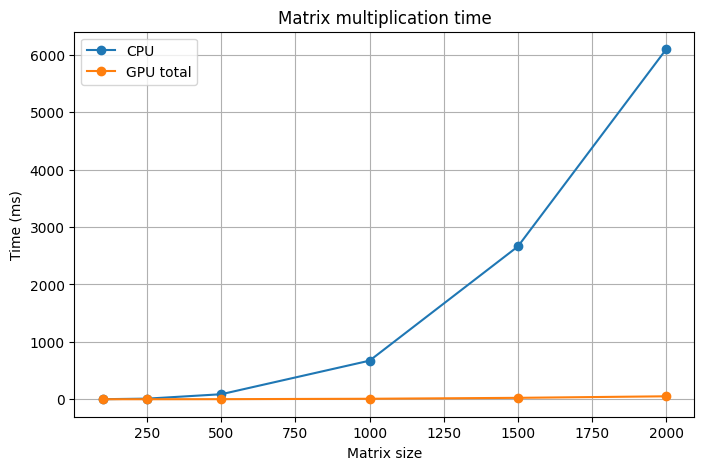

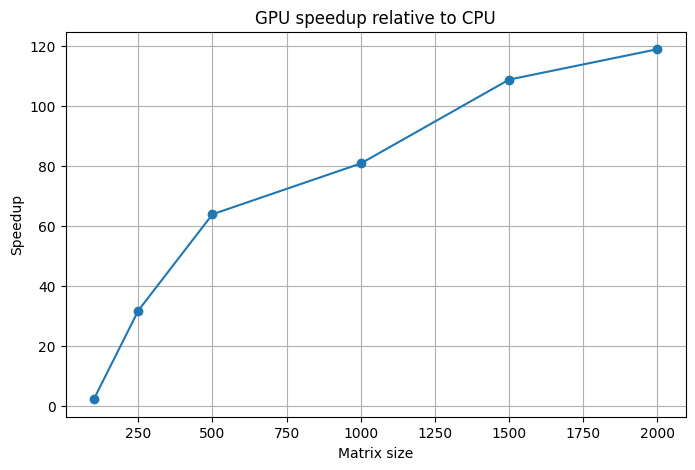

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

plt.figure(figsize=(8, 5))
plt.plot(df["size"], df["cpu_ms"], marker="o", label="CPU")
plt.plot(df["size"], df["gpu_total_ms"], marker="o", label="GPU total")
plt.xlabel("Matrix size")
plt.ylabel("Time (ms)")
plt.title("Matrix multiplication time")
plt.grid(True)
plt.legend()
plt.savefig("time_plot.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["size"], df["speedup_total"], marker="o")
plt.xlabel("Matrix size")
plt.ylabel("Speedup")
plt.title("GPU speedup relative to CPU")
plt.grid(True)
plt.savefig("speedup_plot.png", dpi=150, bbox_inches="tight")
plt.show()